In [3]:
import pandas as pd
import numpy as np
import datetime
import missingno
import sys

sys.path.insert(0, "../../Modules")

from preprocessing_utils import *

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
raw_mosquito_data = pd.read_csv('../data/IT_MSQ_culex_2010-2022.csv', encoding = enc)

In [6]:
raw_mosquito_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8258 entries, 0 to 8257
Data columns (total 93 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   station_id                   8258 non-null   int64  
 1   x                            8258 non-null   float64
 2   y                            8258 non-null   float64
 3   dt_placement                 8258 non-null   object 
 4   week                         7949 non-null   float64
 5   month                        8258 non-null   int64  
 6   year                         8258 non-null   int64  
 7   country_code                 7754 non-null   object 
 8   nuts0_code                   7754 non-null   float64
 9   nuts0_name                   7754 non-null   object 
 10  nuts1_code                   7754 non-null   object 
 11  nuts1_name                   7752 non-null   object 
 12  nuts2_code                   7754 non-null   object 
 13  nuts2_name        

In [7]:
cols = raw_mosquito_data.columns

In [8]:
missing = describe_dataframe(raw_mosquito_data)

In [9]:
cols

Index(['station_id', 'x', 'y', 'dt_placement', 'week', 'month', 'year',
       'country_code', 'nuts0_code', 'nuts0_name', 'nuts1_code', 'nuts1_name',
       'nuts2_code', 'nuts2_name', 'nuts3_code', 'nuts3_name',
       'lau1_municipality', 'lau2_settlement', 'trap_type', 'culex.spp',
       'culex.pipiens', 'no_pools', 'poolsize', 'no_pos_pools', 'wnv_mir',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'image',
       'date', 'deltatime', 'lst_day', 'lst_day_image', 'lst_night',
       'lst_night_image', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'max_wind', 'min_wind', 'mean_wind', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'sp_cnt_1km',
       'biol_cnt_1km', 'wc_l_1km', 'pg_area_1km', 'fs_area_1km',
       'wc_mean_dist_1000', 'coast_mean_dist_1000', 'dem_mean_1km',
       'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km', 'f

In [10]:
drop_cols = ['station_id', 'country_code', 'nuts0_code', 'nuts0_name', 'nuts1_code', 'nuts1_name', 
             'nuts2_code', 'nuts3_code', 'nuts3_name', 'lau1_municipality', 'lau2_settlement', 'trap_type', 
             'culex pipiens', 'culex.pipiens', 'no_pools','poolsize', 'no_pos_pools','wnv_mir', 'image', 'date', 'deltatime',
             'lst_day_image', 'lst_night_image', 'max_wind','min_wind','mean_wind', 'culex pipiens', 'ndi_mission',
             'ndi_acquisition', 'ndi_dates_diff', 'ndi_measures_mission', 'ndi_measures_acquisition', 'ndi_measures_dates_diff',
             'lst_day_mission',  'lst_day_acquisition', 'lst_day_diff', 'lst_night_mission', 'lst_night_acquisition', 
             'lst_night_diff',  'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'culex_spp', 
             'culex_spp_','region', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail', 
             'dt_placement_minus_14_avail', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 
             'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km', 'pg_area_1km', 'fs_area_1km',]
            
raw_mosquito_data.drop(columns=drop_cols, inplace=True)

In [11]:
raw_mosquito_data = raw_mosquito_data.rename(columns=lambda x: re.sub('_new', '', x))

In [12]:
raw_mosquito_data

,x,y,dt_placement,week,month,year,nuts2_name,culex.spp,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,12.877089,45.606292,2010-05-04,18.0,5,2010,Veneto,73.0,0.385414,-0.216246,0.168600,-0.168600,0.373513,0.178836,-0.212464,0.036919,0.157332,0.173466,-0.157332,0.173466,14778.0,14327.0,13921.100000,14226.750000,14523.789470,14699.222220,181.000000,755.338440,2.000000,3.170475,181.852737,188580.173358,0.768354,788.258643,97.924360,108.459687
1,12.213579,45.519400,2010-05-04,18.0,5,2010,Veneto,8.0,0.364547,-0.238592,0.120877,-0.120877,0.352018,0.096370,-0.256190,0.013523,0.099872,0.074789,-0.099872,0.074789,15165.0,14327.0,13966.125000,14118.100000,14439.500000,14884.090910,330.000000,7632.589844,2.000000,4.433795,191.382141,3461.305227,15.542860,761.073186,92.308543,113.680916
2,11.670841,45.559359,2010-05-04,18.0,5,2010,Veneto,7.0,0.527000,-0.260886,0.254624,-0.254624,0.534263,0.190367,-0.263905,0.021883,0.266105,0.184848,-0.266105,0.184848,15089.0,14243.0,13926.272730,14308.571430,14678.235290,14816.000000,431.000000,46648.046875,31.000000,2.488173,88.212029,2466.041522,0.061692,699.050763,105.392731,139.285576
3,11.117869,45.314329,2010-05-04,18.0,5,2010,Veneto,7.0,0.202139,-0.326031,-0.058505,0.058505,0.410308,0.132938,-0.272093,0.060122,0.119556,0.144574,-0.119556,0.144574,14890.0,14386.0,13799.666670,14135.900000,14502.000000,15057.650000,107.000000,81034.250000,26.000000,8.051573,248.790588,0.000000,359.439000,660.088716,106.435548,131.079724
4,12.550696,45.693042,2010-05-04,18.0,5,2010,Veneto,78.0,0.520268,-0.365268,0.128895,-0.128895,0.407513,0.072071,-0.274537,0.055173,0.119583,0.028569,-0.119583,0.028569,15350.0,14237.0,13967.500000,14231.400000,14453.466670,14861.100000,619.000000,13726.019531,1.000000,1.778469,110.403061,0.000000,3.994677,775.208759,84.240548,95.694383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8253,12.450199,44.902272,2022-09-28,39.0,9,2022,NaN,NaN,0.255964,-0.230567,-0.003403,0.003403,0.139171,0.076323,-0.114381,0.064766,-0.012127,0.060118,0.012127,0.060118,14526.0,14355.0,13989.636364,14204.266667,14473.708333,14653.850000,186.000000,936.028137,0.000000,5.487367,98.022560,636884.337952,3.995811,1296.027715,22.086037,41.030620
8254,10.832730,45.356300,2022-09-28,39.0,9,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14929.0,14294.0,14006.250000,14324.666667,14627.058824,14852.250000,348.000000,23904.560547,6.000000,6.421210,239.215118,31147.152764,16.150270,1027.004642,9.188019,33.558730
8255,12.985235,45.771308,2022-09-28,39.0,9,2022,NaN,NaN,0.177560,-0.143246,0.099241,-0.099241,0.207551,0.028039,-0.164080,0.025794,0.123498,0.016626,-0.123498,0.016626,14873.0,14168.0,13970.105263,14230.875000,14503.761905,14774.538462,720.000000,15109.530273,3.000000,3.562778,82.187408,146414.639767,0.648811,1248.774627,44.126634,128.529468
8256,11.897642,45.351147,2022-09-28,39.0,9,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14849.0,14098.0,13957.812500,14259.750000,14559.318182,14875.294118,660.755948,20500.000000,7.901536,0.691991,168.050378,0.404380,303.758511,1426.928093,21.742343,118.606235


<AxesSubplot:>

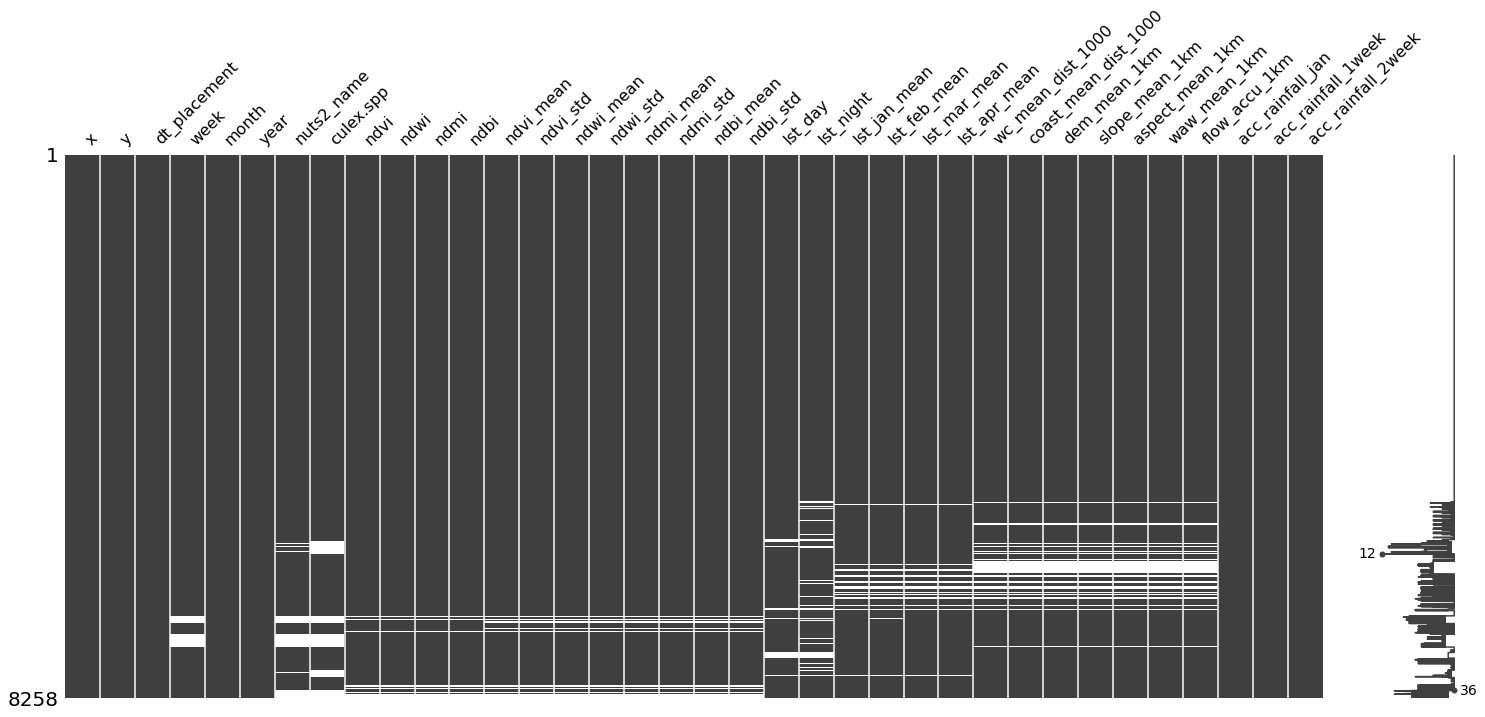

In [13]:
missingno.matrix(raw_mosquito_data)

In [14]:
raw_mosquito_data.dropna(subset=['culex.spp'], inplace=True)

In [15]:
raw_mosquito_data['dt_placement'] = pd.to_datetime(raw_mosquito_data['dt_placement'])
raw_mosquito_data['day'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.day)
raw_mosquito_data['month'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.month)
raw_mosquito_data['year'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.year)
raw_mosquito_data['week'] = raw_mosquito_data.apply(lambda row: datetime.date(row['year'], row['month'], row['day']).isocalendar().week, axis=1)

raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'day', 31)
raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'month', 12)
raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'week', 53)

raw_mosquito_data.rename(columns={"culex.spp": "mosq_now", 'nuts2_name': 'nuts2'}, inplace = True)

In [16]:
raw_mosquito_data

,x,y,dt_placement,week,month,year,nuts2,mosq_now,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,day,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,12.877089,45.606292,2010-05-04,18,5,2010,Veneto,73.0,0.385414,-0.216246,0.168600,-0.168600,0.373513,0.178836,-0.212464,0.036919,0.157332,0.173466,-0.157332,0.173466,14778.0,14327.0,13921.100000,14226.750000,14523.789470,14699.222220,181.000000,755.338440,2.000000,3.170475,181.852737,188580.173358,0.768354,788.258643,97.924360,108.459687,4,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823
1,12.213579,45.519400,2010-05-04,18,5,2010,Veneto,8.0,0.364547,-0.238592,0.120877,-0.120877,0.352018,0.096370,-0.256190,0.013523,0.099872,0.074789,-0.099872,0.074789,15165.0,14327.0,13966.125000,14118.100000,14439.500000,14884.090910,330.000000,7632.589844,2.000000,4.433795,191.382141,3461.305227,15.542860,761.073186,92.308543,113.680916,4,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823
2,11.670841,45.559359,2010-05-04,18,5,2010,Veneto,7.0,0.527000,-0.260886,0.254624,-0.254624,0.534263,0.190367,-0.263905,0.021883,0.266105,0.184848,-0.266105,0.184848,15089.0,14243.0,13926.272730,14308.571430,14678.235290,14816.000000,431.000000,46648.046875,31.000000,2.488173,88.212029,2466.041522,0.061692,699.050763,105.392731,139.285576,4,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823
3,11.117869,45.314329,2010-05-04,18,5,2010,Veneto,7.0,0.202139,-0.326031,-0.058505,0.058505,0.410308,0.132938,-0.272093,0.060122,0.119556,0.144574,-0.119556,0.144574,14890.0,14386.0,13799.666670,14135.900000,14502.000000,15057.650000,107.000000,81034.250000,26.000000,8.051573,248.790588,0.000000,359.439000,660.088716,106.435548,131.079724,4,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823
4,12.550696,45.693042,2010-05-04,18,5,2010,Veneto,78.0,0.520268,-0.365268,0.128895,-0.128895,0.407513,0.072071,-0.274537,0.055173,0.119583,0.028569,-0.119583,0.028569,15350.0,14237.0,13967.500000,14231.400000,14453.466670,14861.100000,619.000000,13726.019531,1.000000,1.778469,110.403061,0.000000,3.994677,775.208759,84.240548,95.694383,4,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8133,13.191821,45.832649,2022-09-28,39,9,2022,Friuli-Venezia-Giulia,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.0,14108.0,13991.526316,14265.941176,14523.739130,14756.125000,40.000000,59814.843750,50.000000,1.920349,247.950577,46418.655962,0.041417,1528.348977,37.809406,117.167325,28,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796
8134,13.191821,45.832649,2022-09-28,39,9,2022,Friuli-Venezia-Giulia,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.0,14108.0,13991.526316,14265.941176,14523.739130,14756.125000,40.000000,59814.843750,50.000000,1.920349,247.950577,46418.655962,0.041417,1528.348977,37.809406,117.167325,28,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796
8135,13.117108,46.019710,2022-09-28,39,9,2022,Friuli-Venezia-Giulia,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14860.0,14313.0,13967.888889,14276.941176,14585.739130,14828.214286,323.623601,27518.180000,77.068546,1.053185,178.457833,0.003570,129.843153,1384.571869,40.493225,100.870455,28,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796
8136,12.255492,45.700641,2022-09-28,39,9,2022,Veneto,2.0,NaN,NaN,NaN,NaN,0.317781,0.028018,-0.285795,0.028248,0.110989,0.012057,-0.110989,0.012057,14713.0,14188.0,13980.850000,14258.928571,14537.523810,14826.062500,290.000000,21010.226563,17.000000,3.309368,142.115463,20159.187074,205.296100,1373.447064,23.130704,67.646951,28,-0.

In [17]:
cols = raw_mosquito_data.columns
cols

Index(['x', 'y', 'dt_placement', 'week', 'month', 'year', 'nuts2', 'mosq_now',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'acc_rainfall_jan', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'day', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos'],
      dtype='object')

In [18]:
len(cols)

43

In [19]:
reorder = [
 'nuts2',
 'x',
 'y',
 'dt_placement',
 'day',
 'month',
 'week',
 'year',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'ndvi',
 'ndwi',
 'ndmi',
 'ndbi',
 'ndvi_mean',
 'ndvi_std',
 'ndwi_mean',
 'ndwi_std',
 'ndmi_mean',
 'ndmi_std',
 'ndbi_mean',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'acc_rainfall_jan',
 'wc_mean_dist_1000',
 'coast_mean_dist_1000',
 'dem_mean_1km',
 'slope_mean_1km',
 'aspect_mean_1km',
 'waw_mean_1km',
 'flow_accu_1km',
 'mosq_now'
 ]

In [20]:
len(reorder)

43

In [21]:
dataset = raw_mosquito_data[reorder].copy()

In [22]:
dataset

,nuts2,x,y,dt_placement,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,ndvi,ndwi,ndmi,ndbi,ndvi_mean,ndvi_std,ndwi_mean,ndwi_std,ndmi_mean,ndmi_std,ndbi_mean,ndbi_std,lst_day,lst_night,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,wc_mean_dist_1000,coast_mean_dist_1000,dem_mean_1km,slope_mean_1km,aspect_mean_1km,waw_mean_1km,flow_accu_1km,mosq_now
0,Veneto,12.877089,45.606292,2010-05-04,4,5,18,2010,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823,0.385414,-0.216246,0.168600,-0.168600,0.373513,0.178836,-0.212464,0.036919,0.157332,0.173466,-0.157332,0.173466,14778.0,14327.0,13921.100000,14226.750000,14523.789470,14699.222220,97.924360,108.459687,788.258643,181.000000,755.338440,2.000000,3.170475,181.852737,188580.173358,0.768354,73.0
1,Veneto,12.213579,45.519400,2010-05-04,4,5,18,2010,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823,0.364547,-0.238592,0.120877,-0.120877,0.352018,0.096370,-0.256190,0.013523,0.099872,0.074789,-0.099872,0.074789,15165.0,14327.0,13966.125000,14118.100000,14439.500000,14884.090910,92.308543,113.680916,761.073186,330.000000,7632.589844,2.000000,4.433795,191.382141,3461.305227,15.542860,8.0
2,Veneto,11.670841,45.559359,2010-05-04,4,5,18,2010,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823,0.527000,-0.260886,0.254624,-0.254624,0.534263,0.190367,-0.263905,0.021883,0.266105,0.184848,-0.266105,0.184848,15089.0,14243.0,13926.272730,14308.571430,14678.235290,14816.000000,105.392731,139.285576,699.050763,431.000000,46648.046875,31.000000,2.488173,88.212029,2466.041522,0.061692,7.0
3,Veneto,11.117869,45.314329,2010-05-04,4,5,18,2010,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823,0.202139,-0.326031,-0.058505,0.058505,0.410308,0.132938,-0.272093,0.060122,0.119556,0.144574,-0.119556,0.144574,14890.0,14386.0,13799.666670,14135.900000,14502.000000,15057.650000,106.435548,131.079724,660.088716,107.000000,81034.250000,26.000000,8.051573,248.790588,0.000000,359.439000,7.0
4,Veneto,12.550696,45.693042,2010-05-04,4,5,18,2010,0.724793,0.688967,0.5,-8.660254e-01,0.845596,-0.533823,0.520268,-0.365268,0.128895,-0.128895,0.407513,0.072071,-0.274537,0.055173,0.119583,0.028569,-0.119583,0.028569,15350.0,14237.0,13967.500000,14231.400000,14453.466670,14861.100000,84.240548,95.694383,775.208759,619.000000,13726.019531,1.000000,1.778469,110.403061,0.000000,3.994677,78.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8133,Friuli-Venezia-Giulia,13.191821,45.832649,2022-09-28,28,9,39,2022,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.0,14108.0,13991.526316,14265.941176,14523.739130,14756.125000,37.809406,117.167325,1528.348977,40.000000,59814.843750,50.000000,1.920349,247.950577,46418.655962,0.041417,2.0
8134,Friuli-Venezia-Giulia,13.191821,45.832649,2022-09-28,28,9,39,2022,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.0,14108.0,13991.526316,14265.941176,14523.739130,14756.125000,37.809406,117.167325,1528.348977,40.000000,59814.843750,50.000000,1.920349,247.950577,46418.655962,0.041417,3.0
8135,Friuli-Venezia-Giulia,13.117108,46.019710,2022-09-28,28,9,39,2022,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14860.0,14313.0,13967.888889,14276.941176,14585.739130,14828.214286,40.493225,100.870455,1384.571869,323.623601,27518.180000,77.068546,1.053185,178.457833,0.003570,129.843153,1.0
8136,Veneto,12.255492,45.700641,2022-09-28,28,9,39,2022,-0.571268,0.820763,-1.0,-1.836970e-16,-0.996050,-0.088796,NaN,NaN,NaN,NaN,0.317781,0.028018,-0.285795,0.028248,0.110989,0.012057,-0.110989,0.012057,14713.0,14188.0,13980.850000,14258.928571,14537.523810,14826.062500,23.130704,67.646951,1373.447064,290.000000,21010.226563,17.

<AxesSubplot:>

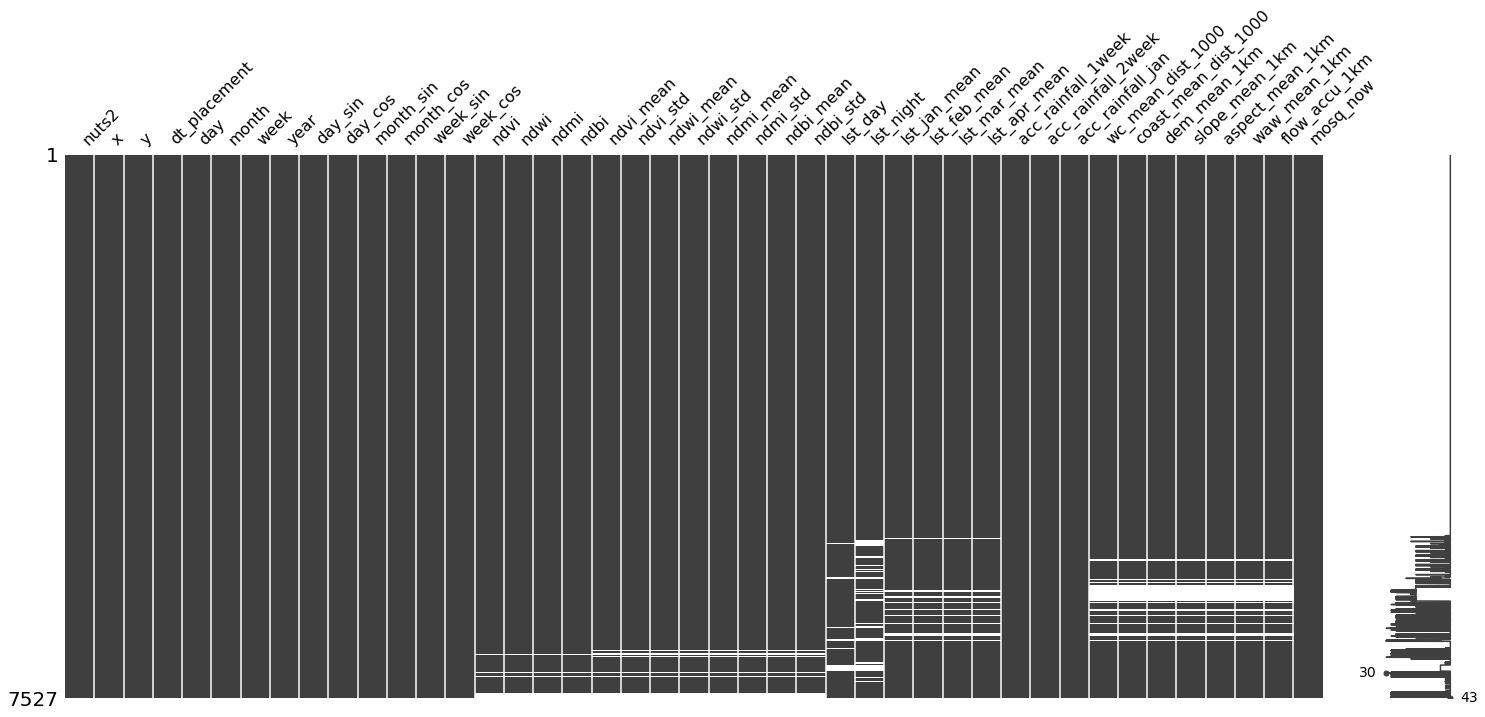

In [23]:
missingno.matrix(dataset)

In [24]:
dataset.to_csv("../data/IT_MSQ_culex_2010-2022_processed.csv", encoding = enc, index = False)